# Telco Churn Prediction 

In [1]:
#load libraries 
import numpy as np
import pandas as pd
import  seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#load data set 
df =pd.read_csv('Telco-Customer-Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Exploration & Cleaning (EDA)


### Understanding the Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print(df.isnull().sum())
print(df.describe())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [5]:
df.shape

(7043, 21)

#### 2. Fix:"Totalcharges"
#####  This column often imports as an Object (string) because of blank spaces " " for customers with 0 tenure.
##### We force it to numeric, turning errors (blanks) into NaN, then fill them with 0.

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.fillna({'TotalCharges': 0}, inplace=True)

#### 3.Drop CustomerID 
##### This is a unique identifier and has no predictive power 

In [7]:
df.drop(columns=['customerID'], inplace=True)

#### 4. Convert Target 'Churn' to Binary (0/1)
##### Machine learning models require numbers, not "Yes"/"No".

##### "Yes" (1): This means the customer left the company. They cancelled their subscription or contract. These are the people you want to identify early so you can try to keep them.
##### "No" (0): This means the customer stayed. They are still an active subscriber.

Churn
0    5174
1    1869
Name: count, dtype: int64


C:\Users\Menuja\AppData\Local\Temp\ipykernel_3564\91973460.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='coolwarm')


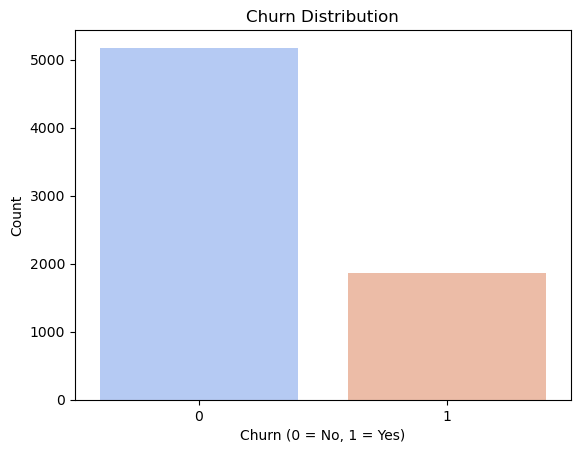

In [8]:
df['Churn']= df['Churn'].map({'Yes':1,'No':0})
print(df['Churn'].value_counts())
sns.countplot(x='Churn', data=df, palette='coolwarm')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

#####  Graph : Numerical Distributions 

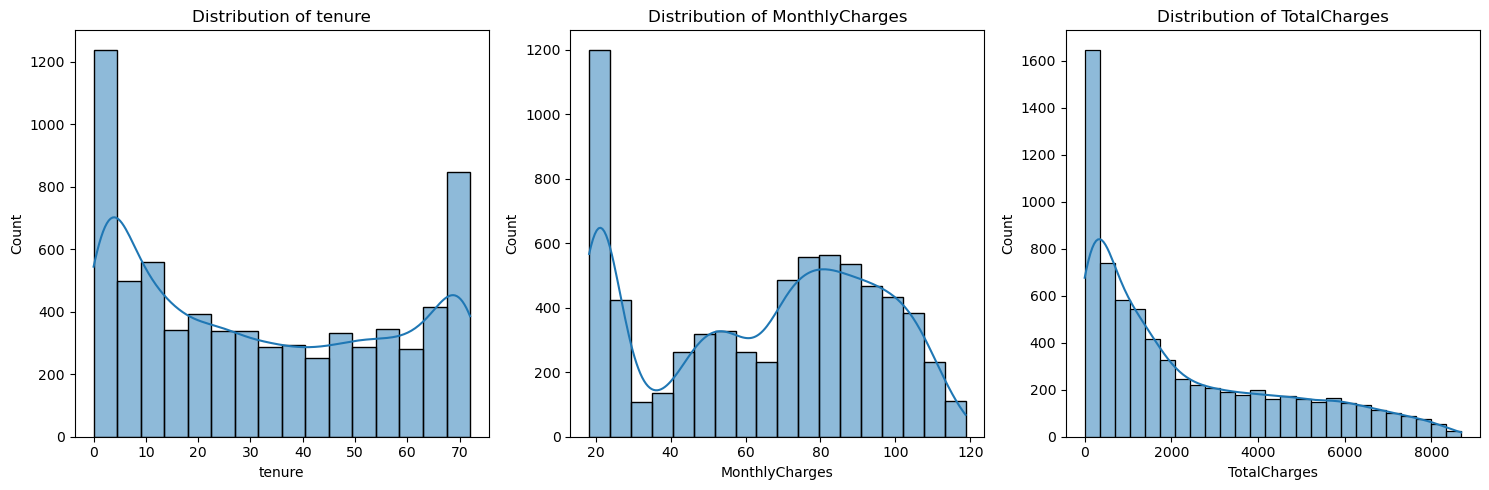

In [9]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


#####  Graph : Boxplots (Outliers)

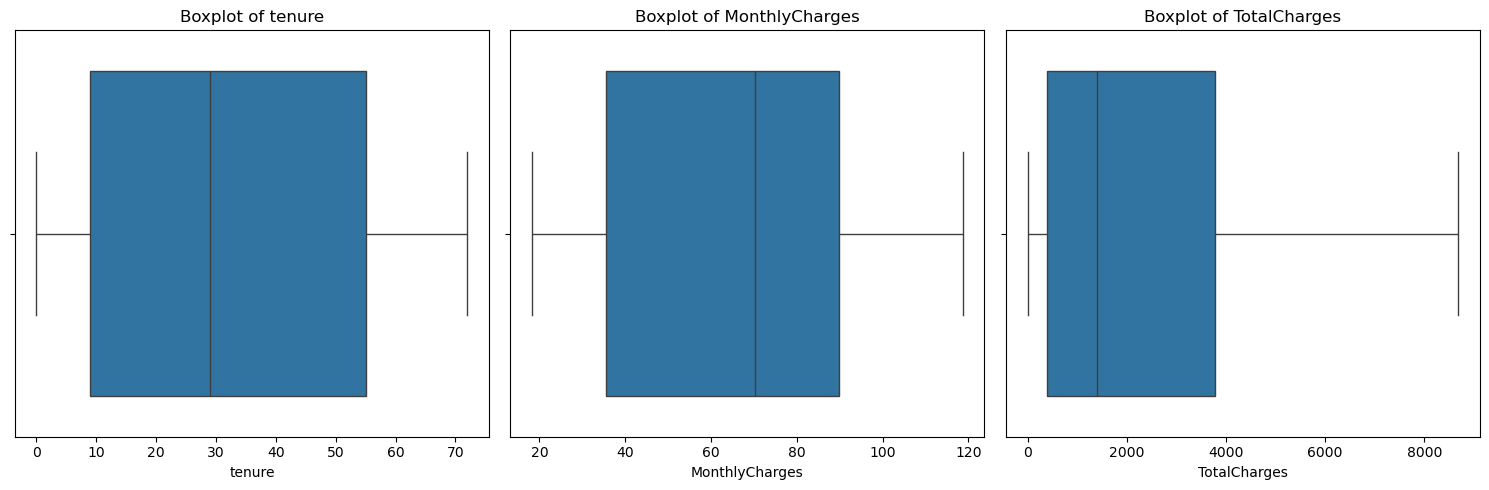

In [10]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

##### Distribution Plots
##### Per your request, the Y-axis is Churn and the X-axis represents the three numerical variables (tenure, MonthlyCharges, TotalCharges).

##### Tenure: You can see a clear pattern. Churn (Orange/1) is heavily concentrated in the low tenure range (new customers), while retained customers (Blue/0) are spread out but generally have higher tenure.

##### MonthlyCharges: Churners tend to have higher monthly charges (median is higher).

##### TotalCharges: The distribution is skewed for both, but churners generally have lower total charges simply because they leave before accumulating a large total.

##### Boxplots (Y-Axis = Churn)

##### Histograms (Detailed Distribution Shape) I also generated histograms because they show the "shape" of the data better (e.g., the massive spike of churners at 0-10 months).

C:\Users\Menuja\AppData\Local\Temp\ipykernel_3564\3485401009.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Churn'].astype(str), order=['0', '1'], palette='coolwarm')
C:\Users\Menuja\AppData\Local\Temp\ipykernel_3564\3485401009.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Churn'].astype(str), order=['0', '1'], palette='coolwarm')
C:\Users\Menuja\AppData\Local\Temp\ipykernel_3564\3485401009.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Churn'].astype(str), order=['0', '1'], 

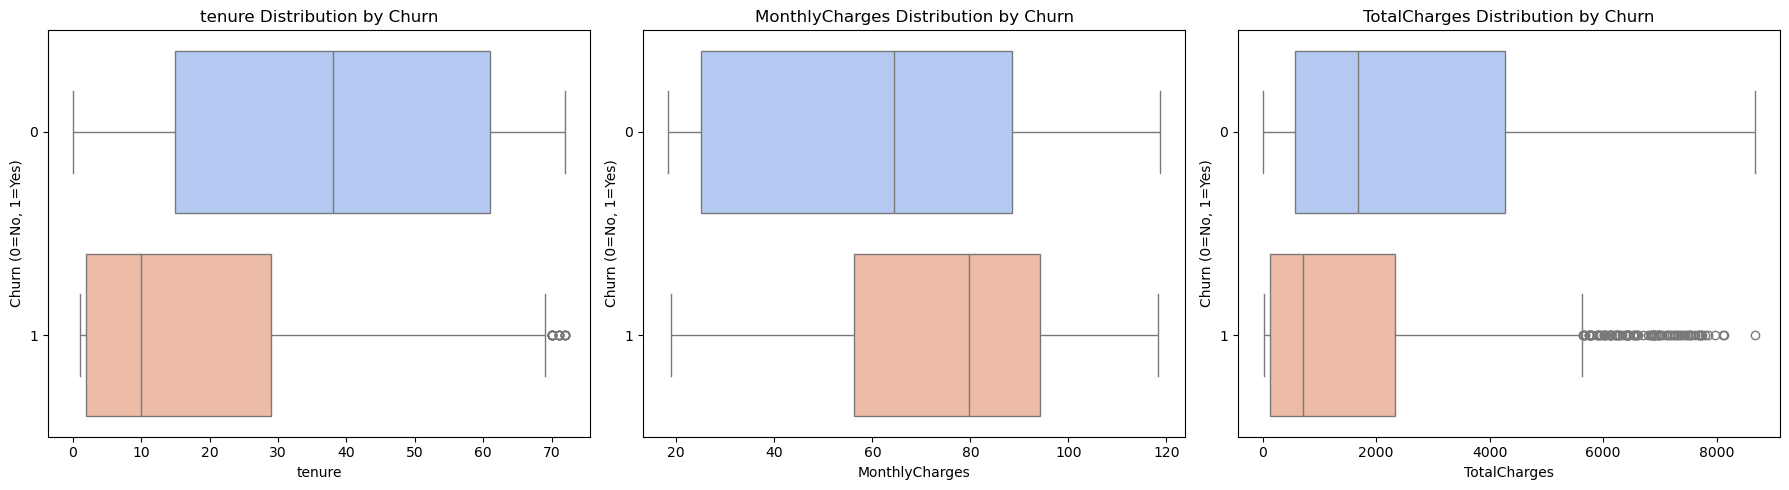

In [11]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    
    # We convert Churn to string ('0', '1') temporarily so the Y-axis is treated as categorical
    sns.boxplot(x=df[col], y=df['Churn'].astype(str), order=['0', '1'], palette='coolwarm')
    
    plt.title(f'{col} Distribution by Churn')
    plt.xlabel(col)
    plt.ylabel('Churn (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

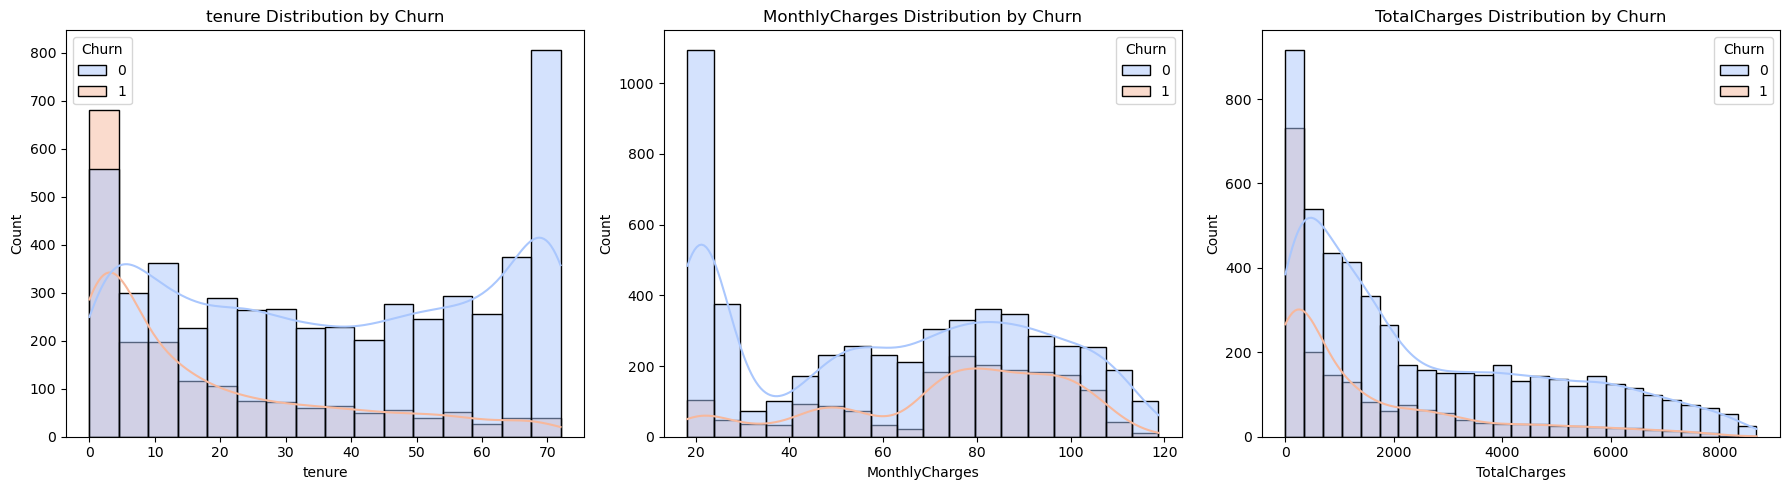

In [12]:
plt.figure(figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    
    # We use 'hue' to color by Churn
    # kde=True adds the smooth curve
    # common_norm=False allows us to compare shapes even though counts are different
    sns.histplot(data=df, x=col, hue='Churn', kde=True, palette='coolwarm', common_norm=False)
    
    plt.title(f'{col} Distribution by Churn')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [13]:
print("Data loaded and cleaned")
print(f"Dataset Shape:{df.shape}")
df.info

Data loaded and cleaned
Dataset Shape:(7043, 20)


<bound method DataFrame.info of       gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL       

## Preprocessing (Encoding and Scaling)

##### Machine learning models cannot understand text like "Male" or "Fiber Optic". We must translate these into numbers (Encoding) and ensure numerical values are on the same scale (Scaling).

In [14]:
from sklearn.preprocessing import StandardScaler

##### Identify Column Type

In [15]:
categorical_cols=[c for c in df.columns if df[c].dtype =='object']
numerical_cols=['tenure','MonthlyCharges','TotalCharges']

#### One-Hot Encoding 
##### converts categorical variables  into binary columns (e.g., InternetService -> InternetService_DSL, InternetService_Fiber)
##### drop_first=True avoids multicollinearity (e.g., if we know it's not Male, it must be Female).

In [16]:
df_encoded= pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#### scaling Numerical Features 
##### scales 'tenure', 'MonthlyCharges', etc., so larger numbers don't dominate the model.

In [17]:
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("Data Preprocessed.")
df_encoded.head()

## Train-Test Split

##### We split the data to ensure we have a hidden set of data (Test Set) to evaluate how well the model performs on new, unseen customers.

In [18]:
from sklearn.model_selection import train_test_split

##### Define Features (X) and Target (y)

In [19]:
X= df_encoded.drop('Churn', axis=1)
y= df_encoded['Churn']

##### Split: 80% for Training, 20% for Testing

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Testing shapes:  X={X_test.shape},  y={y_test.shape}")

Training shapes: X=(5634, 30), y=(5634,)
Testing shapes:  X=(1409, 30),  y=(1409,)


## Model Training (Logistic Regression)

##### We use Logistic Regression as a baseline. It provides good accuracy and is highly interpretable, allowing us to see which features drive churn.

In [22]:
from sklearn.linear_model import LogisticRegression

##### Initialize and Train
##### max_iter=1000 ensures the solver has enough time to find the best fit

In [23]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model Training Complete.")

Model Training Complete.


## Evaluation


##### Since churn is an "imbalanced" problem (fewer people churn than stay), Accuracy can be misleading. We focus on Recall (catching the churners) and the Confusion Matrix.

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

##### Generate Predictions

In [25]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability estimates

In [26]:
#accuracy
print("--- accuracy ---")
model.score(X_test,y_test)

--- accuracy ---


0.8211497515968772

##### 1. Classification Report

In [27]:
print("\n--- Logistic Regression ---")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Logistic Regression ---

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



##### 2. Confusion Matrix Heatmap

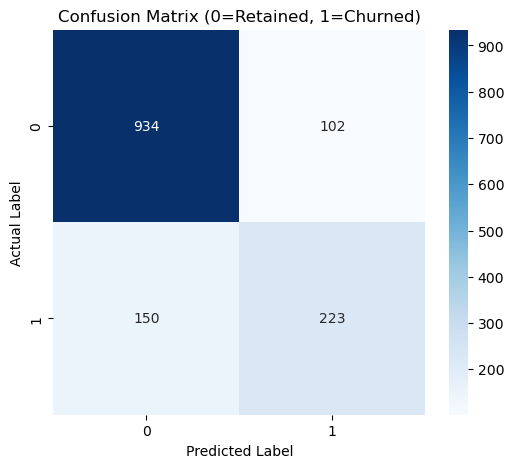

In [28]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (0=Retained, 1=Churned)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

##### 3. ROC-AUC Score
##### A score closer to 1.0 indicates a better model.

In [29]:
roc_score = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_score:.4f}")

ROC-AUC Score: 0.8622


## Feature Importance

##### This step visualizes why the model makes its decisions, helping business teams understand the drivers of churn (e.g., Fiber Optic service, Month-to-month contracts).

##### Extract coefficients from the model

In [30]:
weights = pd.Series(model.coef_[0], index=X.columns)
weights = weights.sort_values(ascending=False)

##### Plot top 10 Positive (Churn Drivers) and Negative (Retention Drivers) features

#####  Combine top 10 and bottom 10 for a clean vie

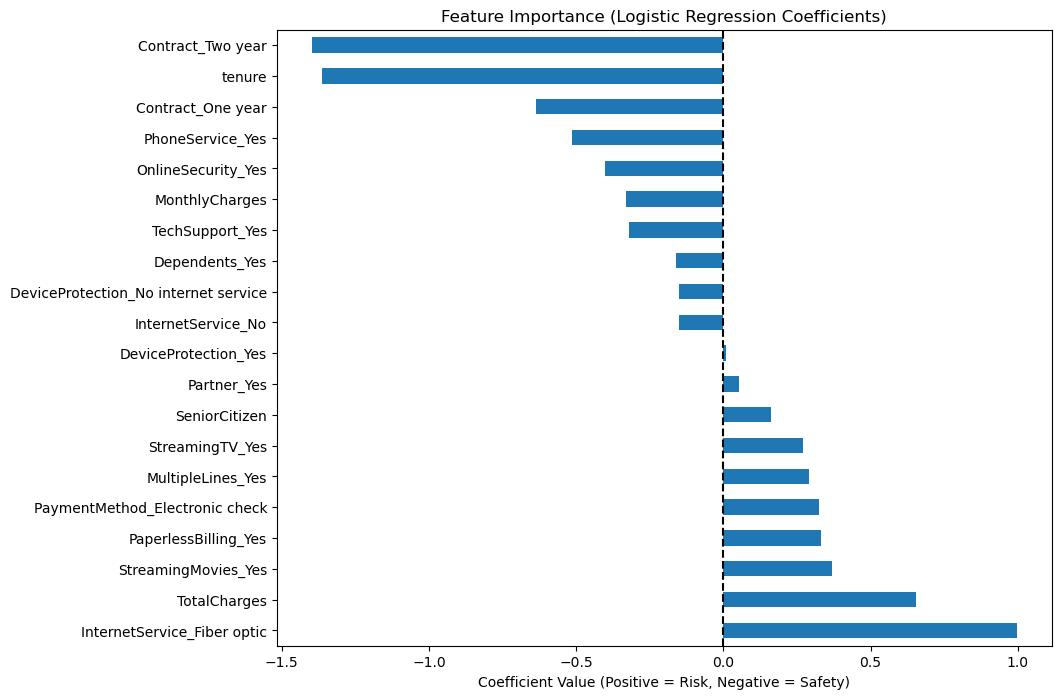

Top Churn Risks (Positive Coefs):
InternetService_Fiber optic       0.996214
TotalCharges                      0.653440
StreamingMovies_Yes               0.368102
PaperlessBilling_Yes              0.332748
PaymentMethod_Electronic check    0.324171
dtype: float64


In [31]:
plt.figure(figsize=(10, 8))
top_features = pd.concat([weights.head(10), weights.tail(10)])
top_features.plot(kind='barh')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value (Positive = Risk, Negative = Safety)")
plt.axvline(0, color='black', linestyle='--')
plt.show()

print("Top Churn Risks (Positive Coefs):")
print(weights.head(5))

###  Train Random Forest
##### n_estimators=100 means "Build 100 decision trees and average them"

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [33]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluation

In [34]:
y_pred = rf_model.predict(X_test)
print("--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Random Forest Performance ---
Accuracy: 78.64%

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.44      0.52       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.79      0.77      1409



### Confusion Matrix

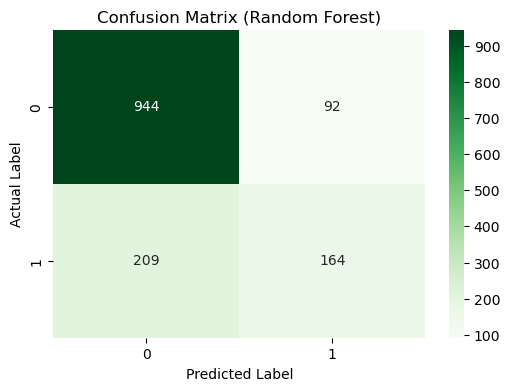

In [35]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Random Forest)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 8. Feature Importance (The "Why")
##### This shows which columns had the biggest impact on the decision

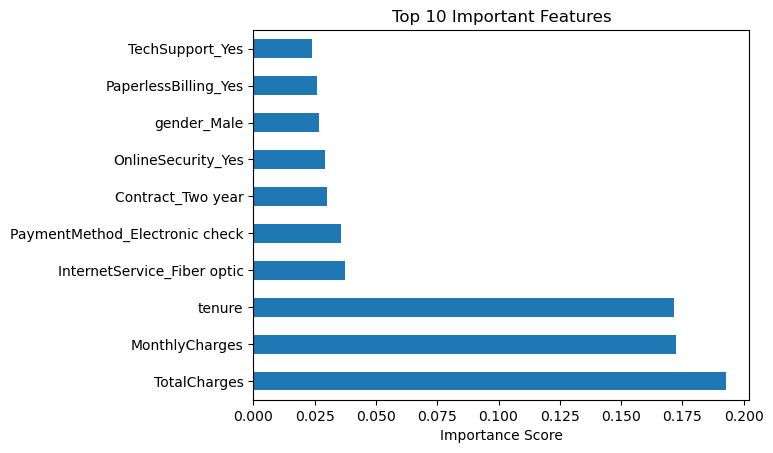

In [36]:

import pandas as pd
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

### Train Decision Tree
##### max_depth=4 limits the tree size so it doesn't overfit and is easier to read


#### Why use a Decision Tree?
##### Pros: It is the most "human-readable" model. You can actually see the rules it creates (e.g., "IF Contract = Month-to-Month, THEN Check Monthly Charges").

##### Cons: It is prone to overfitting (memorizing the data) if you don't limit its depth.

In [37]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [38]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=4) 
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Evaluation

In [39]:
y_pred = dt_model.predict(X_test)

print("--- Decision Tree Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Decision Tree Performance ---
Accuracy: 80.27%

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.53      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### Confusion Matrix

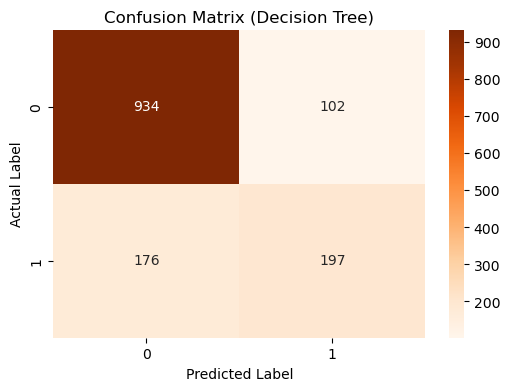

In [40]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix (Decision Tree)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Visualize the Tree (The Best Part!)

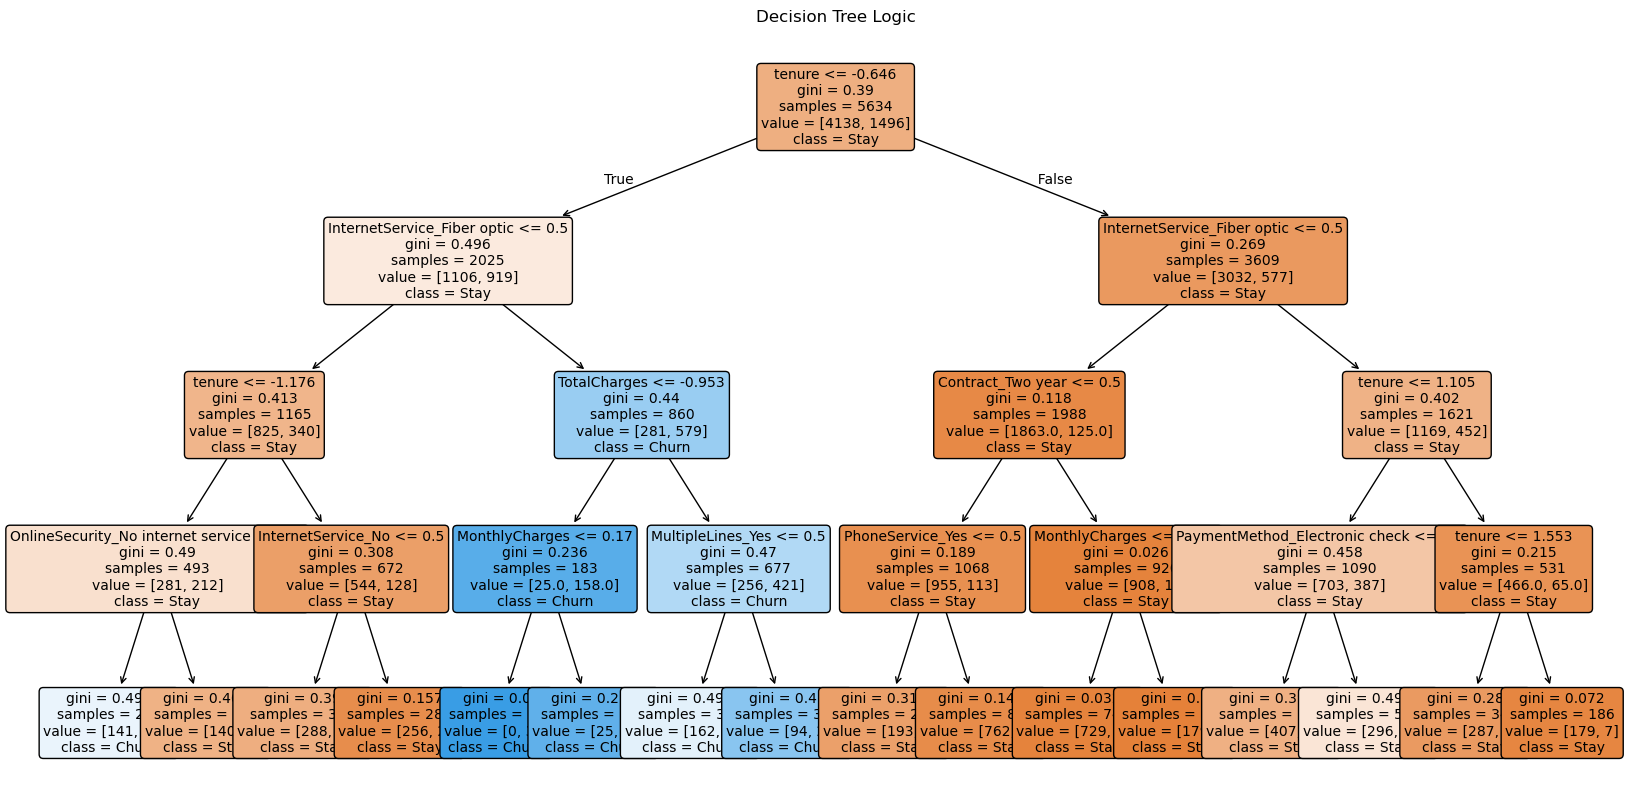

In [41]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=['Stay', 'Churn'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree Logic")
plt.show()

### Train XGBoost
##### use_label_encoder=False avoids a warning in newer versions
##### eval_metric='logloss' helps it converge faster for binary classification

In [42]:
!pip install xgboost

In [43]:
from xgboost import XGBClassifier, plot_importance

In [44]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

C:\Users\Menuja\anaconda3\envs\datascience\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:12:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


#### Evaluation

In [45]:
y_pred = xgb_model.predict(X_test)

print("--- XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- XGBoost Performance ---
Accuracy: 79.13%

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.63      0.52      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



#### Confusion Matrix

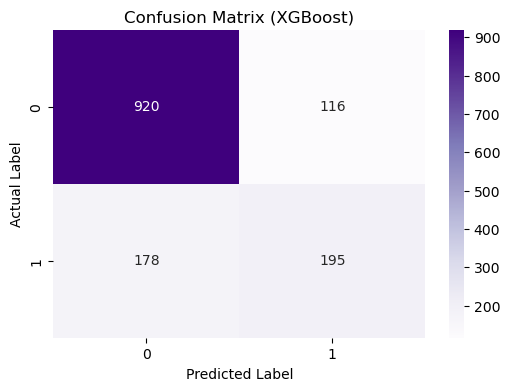

In [46]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix (XGBoost)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

#### Feature Importance

<Figure size 1000x800 with 0 Axes>

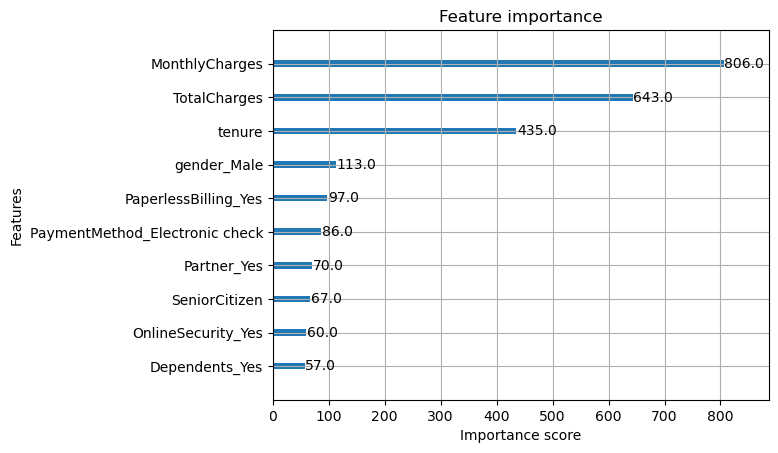

In [47]:
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=10) # XGBoost has a built-in plotter!
plt.show()

### 5. Scaling (CRITICAL FOR SVM)
##### SVM calculates distances. If 'TotalCharges' is 8000 and 'tenure' is 5, 
##### SVM will think TotalCharges is 1000x more important.
##### StandardScaler forces all features to have a mean of 0 and variance of 1.

In [48]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Why use SVM?
##### Pros: It is very good at finding a clear "boundary" or "margin" between the customers who stay and those who leave, even in high-dimensional space (when you have many variables).

##### Cons: It is very slow on large datasets and is harder to interpret than a Decision Tree.

##### Critical Requirement: You MUST scale your data (make all numbers roughly the same size) or SVM will fail. I have included this step in the code below.

### Train SVM
##### kernel='rbf' allows it to draw curved lines (non-linear) to separate the groups
##### probability=True allows us to see the % chance of churn later

In [50]:
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Evaluation

In [51]:
y_pred = svm_model.predict(X_test_scaled)

print("--- SVM Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- SVM Performance ---
Accuracy: 81.41%

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.53      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.81      1409



### Confusion Matrix

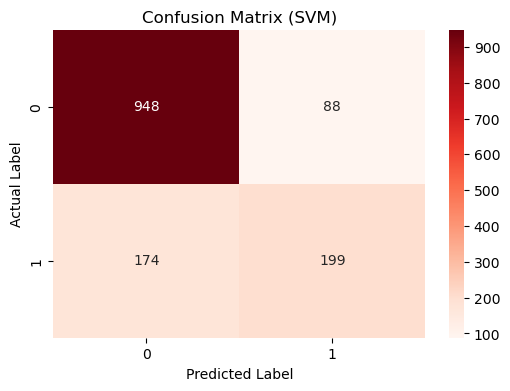

In [52]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix (SVM)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [53]:
import joblib

#####  1. Save the best model (assuming 'rf_model' is your best one)

In [54]:
joblib.dump(rf_model, 'churn_model.pkl')

['churn_model.pkl']

##### 2. Save the scaler (CRITICAL: The website needs to scale inputs exactly like the training data)


In [55]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

##### 3. Save the column names (so we know the exact order of features)

In [56]:
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']

In [57]:
print("Model, Scaler, and Columns saved successfully!")

Model, Scaler, and Columns saved successfully!


In [66]:
# 3. Create a BRAND NEW Scaler and fit it ONLY on these 3 columns
joblib.dump(model, 'churn_model.pkl')
new_scaler = StandardScaler()
new_scaler.fit(df[numerical_cols])

,copy,True
,with_mean,True
,with_std,True


In [67]:
# 4. Save this new, specific scaler
joblib.dump(model, 'churn_model.pkl')
joblib.dump(new_scaler, 'scaler.pkl')
print("✅ Scaler fixed! It now expects only 3 columns.")

✅ Scaler fixed! It now expects only 3 columns.
